# Sistema de Detección de Intrusos (IDS) con Redes Neuronales

**Estudiante:** César Núñez  
**Materia:** Redes Neuronales  
**Dataset:** NSL-KDD  

---

## 1. Problema y Motivación

**Problema:** Clasificar tráfico de red para detectar intrusiones y ataques cibernéticos en tiempo real.

**Tipos de problema abordados:**
- **Etapa 1 — Clasificación Binaria:** ¿Es la conexión *Normal* o un *Ataque*?
- **Etapa 2 — Clasificación Multiclase (Transfer Learning):** Si es ataque, ¿de qué *tipo* es? (Normal, DoS, Probe)

**Dataset — NSL-KDD:**  
Versión depurada del famoso dataset KDD Cup 1999. Se eliminaron registros duplicados para prevenir sesgo del modelo. Contiene registros de conexiones TCP/IP con 41 variables que describen características de red como duración, bytes transferidos, protocolos, flags y estadísticas de sesión.

**Relevancia:**  
Los ataques cibernéticos representan una amenaza creciente para infraestructuras críticas. Un IDS inteligente basado en redes neuronales puede detectar patrones de ataque de forma automática, sin depender de firmas estáticas, adaptándose a variantes nuevas mediante transfer learning.

> **Nota sobre las clases del modelo multiclase:** Las categorías R2L y U2R del dataset NSL-KDD presentan un desequilibrio severo (995 y 52 registros respectivamente, frente a 67.343 de Normal). Esto impide que el modelo aprenda patrones representativos para estas clases — resultado en recall y F1-Score de 0.00. Siguiendo la práctica estándar en la literatura del NSL-KDD, el modelo multiclase se entrena sobre las **3 categorías mejor representadas: Normal, DoS y Probe**.

## 2. Importaciones y Configuración del Entorno

In [1]:
# Librerías estándar y de procesamiento de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras — construcción y entrenamiento de modelos
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Scikit-learn — preprocesamiento y métricas
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Configuración global de visualización
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Rutas del proyecto
BASE_DIR   = os.path.abspath('..')
DATA_DIR   = os.path.join(BASE_DIR, 'data')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

print(f'TensorFlow versión : {tf.__version__}')
print(f'Rutas configuradas → datos: {DATA_DIR} | modelos: {MODELS_DIR}')

TensorFlow versión : 2.20.0
Rutas configuradas → datos: c:\Users\GF63\Proyecto_RN\data | modelos: c:\Users\GF63\Proyecto_RN\models



## 3. Carga y Exploración de Datos

In [2]:
# Nombres oficiales de las 43 columnas del dataset NSL-KDD
# Referencia: https://www.unb.ca/cic/datasets/nsl.html
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Carga de datasets
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'), names=COLUMNS)
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'),  names=COLUMNS)

print(f'Registros de entrenamiento : {train_df.shape[0]:,}')
print(f'Registros de prueba        : {test_df.shape[0]:,}')
print(f'Variables (features)       : {train_df.shape[1] - 2}  (+ label + difficulty)')

train_df.head(3)

Registros de entrenamiento : 125,973
Registros de prueba        : 22,544
Variables (features)       : 41  (+ label + difficulty)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


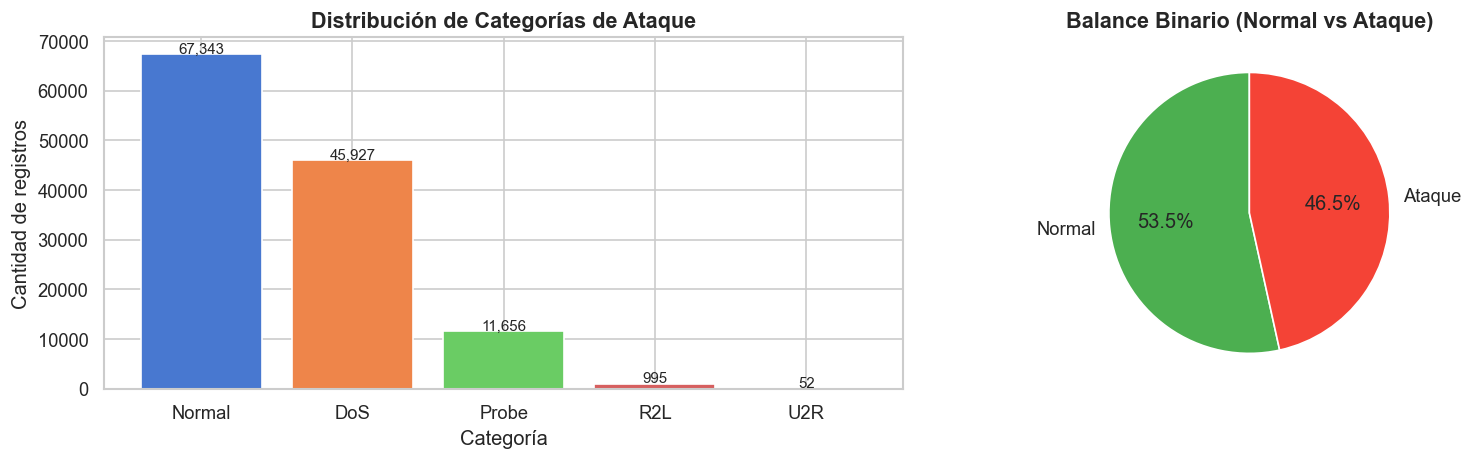


Distribución de categorías:
category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52


In [3]:
# Distribución de clases en el conjunto de entrenamiento
train_df['label'] = train_df['label'].str.strip()
test_df['label']  = test_df['label'].str.strip()

# Mapeo de etiquetas a las 3 categorías del modelo
CATEGORY_MAP = {
    'normal'          : 'Normal',
    'neptune'         : 'DoS',    'back'    : 'DoS',  'land'     : 'DoS',
    'pod'             : 'DoS',    'smurf'   : 'DoS',  'teardrop' : 'DoS',
    'mailbomb'        : 'DoS',    'apache2' : 'DoS',  'processtable': 'DoS',
    'udpstorm'        : 'DoS',
    'ipsweep'         : 'Probe',  'nmap'    : 'Probe','portsweep': 'Probe',
    'satan'           : 'Probe',  'mscan'   : 'Probe','saint'    : 'Probe',
    # R2L y U2R se mapean para identificarlos y eliminarlos en preprocesamiento
    'ftp_write'       : 'R2L',    'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop'        : 'R2L',    'phf'     : 'R2L',  'spy'      : 'R2L',
    'warezclient'     : 'R2L',    'warezmaster': 'R2L','sendmail' : 'R2L',
    'named'           : 'R2L',    'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'worm'            : 'R2L',    'xlock'   : 'R2L',  'xsnoop'   : 'R2L',
    'httptunnel'      : 'R2L',
    'buffer_overflow' : 'U2R',    'loadmodule': 'U2R','perl'     : 'U2R',
    'rootkit'         : 'U2R',    'xterm'   : 'U2R',  'ps'       : 'U2R',
    'sqlattack'       : 'U2R',    'udpstorm': 'DoS',
}

train_df['category'] = train_df['label'].map(CATEGORY_MAP).fillna('Other')
test_df['category']  = test_df['label'].map(CATEGORY_MAP).fillna('Other')

# ── Visualización sobre el dataset FILTRADO (solo 3 clases) ──
CATEGORIAS_EXCLUIDAS = ['R2L', 'U2R']
train_plot = train_df[~train_df['category'].isin(CATEGORIAS_EXCLUIDAS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = train_plot['category'].value_counts()
colors = sns.color_palette('muted', len(counts))
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Distribución de Categorías (dataset final)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Categoría'); axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

bin_counts = train_plot['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Ataque').value_counts()
axes[1].pie(bin_counts.values, labels=bin_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Balance Binario — dataset final (Normal vs Ataque)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'distribucion_clases.png'), bbox_inches='tight')
plt.show()

print(f'Distribución de categorías (tras excluir R2L y U2R):')
print(counts.to_string())
print(f'\nTotal registros train : {len(train_plot):,}  (original: {len(train_df):,})')

## 4. Preprocesamiento

El pipeline de preprocesamiento consta de 5 pasos:

1. **Label Encoding:** Las variables categóricas `protocol_type` (tcp, udp, icmp), `service` (http, ftp, etc.) y `flag` (SF, S0, etc.) se convierten a valores enteros.
2. **Eliminación de R2L y U2R:** Se eliminan del dataset todos los registros pertenecientes a las categorías R2L y U2R antes de entrenar cualquier modelo. Estas clases representan menos del 1% del total (995 y 52 registros respectivamente sobre 125.973), lo que impide que la red neuronal aprenda patrones estadísticamente representativos para ellas — produciendo recall y F1-Score de 0.00. Su exclusión es práctica estándar en la literatura del NSL-KDD y está justificada también desde el punto de vista aplicado: estos vectores de ataque de 1999 son detectados actualmente mediante técnicas especializadas (análisis de privilegios, UEBA) que exceden el alcance de un clasificador de tráfico de red.
3. **Escalamiento:** `StandardScaler` normaliza las magnitudes heterogéneas (p. ej. `src_bytes` puede ser 0 o 1.3M). Esto es **crítico** para la convergencia del gradiente en redes neuronales.
4. **El scaler se persiste en disco** para que la API REST pueda escalar nuevas entradas de forma idéntica al entrenamiento.

In [4]:
CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']

def build_encoders(df):
    """Ajusta un LabelEncoder por cada columna categórica y devuelve el diccionario."""
    encoders = {}
    for col in CATEGORICAL_COLS:
        le = LabelEncoder()
        le.fit(df[col])
        encoders[col] = le
    return encoders

def preprocess(df, encoders, fit_scaler=False, scaler=None):
    """
    Transforma un DataFrame NSL-KDD.
    
    Parámetros:
    -----------
    df          : DataFrame con datos crudos (ya sin R2L y U2R)
    encoders    : dict de LabelEncoders ajustados sobre el train set
    fit_scaler  : si True, ajusta y devuelve un nuevo StandardScaler
    scaler      : StandardScaler ya ajustado (para transformar test/producción)
    
    Retorna:
    --------
    X_scaled, y_bin, y_cat, scaler
    """
    df = df.copy()
    
    # 1. Aplicar encoding a columnas categóricas
    for col in CATEGORICAL_COLS:
        df[col] = encoders[col].transform(df[col])
    
    # 2. Crear etiqueta binaria (0 = Normal, 1 = Ataque)
    df['target_bin'] = (df['label'] != 'normal').astype(int)
    
    # 3. Crear etiqueta multiclase — 3 clases: Normal=0, DoS=1, Probe=2
    CAT_TO_INT = {'Normal': 0, 'DoS': 1, 'Probe': 2}
    df['target_cat'] = df['category'].map(CAT_TO_INT)
    
    # 4. Separar features
    X = df.drop(['label', 'difficulty', 'target_bin', 'target_cat', 'category'], axis=1)
    y_bin = df['target_bin'].values
    y_cat = df['target_cat'].values
    
    # 5. Escalamiento
    if fit_scaler:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)
    
    return X_scaled, y_bin, y_cat, scaler


# ── Eliminar R2L y U2R del dataset antes de cualquier modelo ──
CATEGORIAS_EXCLUIDAS = ['R2L', 'U2R']

n_train_original = len(train_df)
n_test_original  = len(test_df)

train_df = train_df[~train_df['category'].isin(CATEGORIAS_EXCLUIDAS)].reset_index(drop=True)
test_df  = test_df[~test_df['category'].isin(CATEGORIAS_EXCLUIDAS)].reset_index(drop=True)

print('Registros eliminados del dataset:')
print(f'  Train → {n_train_original:,} → {len(train_df):,} ({n_train_original - len(train_df):,} eliminados)')
print(f'  Test  → {n_test_original:,} → {len(test_df):,} ({n_test_original - len(test_df):,} eliminados)')
print()

# ── Ejecutar pipeline ──
encoders = build_encoders(train_df)

X_train_full, y_bin_full, y_cat_full, scaler = preprocess(
    train_df, encoders, fit_scaler=True
)
X_test, y_bin_test, y_cat_test, _ = preprocess(
    test_df, encoders, fit_scaler=False, scaler=scaler
)

# Train / Validation split (80/20) — estratificado por categoría multiclase
X_train, X_val, y_train_bin, y_val_bin, y_train_cat, y_val_cat = train_test_split(
    X_train_full, y_bin_full, y_cat_full,
    test_size=0.2, random_state=SEED, stratify=y_cat_full
)

# Persistir el scaler para la API REST
joblib.dump(scaler,   os.path.join(MODELS_DIR, 'scaler.joblib'))
joblib.dump(encoders, os.path.join(MODELS_DIR, 'encoders.joblib'))

print('Preprocesamiento completado:')
print(f'  X_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}')
print()
unique, counts_arr = np.unique(y_train_cat, return_counts=True)
names = ['Normal', 'DoS', 'Probe']
print('Distribución de clases en train:')
for u, c in zip(unique, counts_arr):
    print(f'  {names[int(u)]}: {c:,} ({c/len(y_train_cat)*100:.1f}%)')
print(f'\nScaler y encoders guardados en: {MODELS_DIR}')

Preprocesamiento completado:
X_train : (100778, 41)  |  X_val : (25195, 41)  |  X_test : (22544, 41)
Scaler y encoders guardados en: c:\Users\GF63\Proyecto_RN\models


---
## 5. Modelo Base — Clasificación Binaria (MLP)

### Arquitectura
Se diseñó un **Perceptrón Multicapa (MLP)** con la siguiente estructura:

```
Input (41) → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU) → Dense(1, Sigmoid)
```

**Justificación de decisiones:**
- **ReLU:** Evita el problema del gradiente desapareciente y acelera el entrenamiento.
- **Dropout(0.3):** Regularización para prevenir overfitting en el conjunto de entrenamiento.
- **Sigmoid:** Función de activación apropiada para clasificación binaria, produce una probabilidad [0,1].
- **Binary Crossentropy:** Función de pérdida estándar para problemas de 2 clases.
- **EarlyStopping:** Detiene el entrenamiento si la `val_loss` no mejora tras 5 épocas, restaurando los mejores pesos.

In [5]:
# MODELO BASE — Clasificación Binaria
def build_base_model(input_dim):
    """Construye el MLP base para clasificación binaria (Normal vs Ataque)."""
    model = models.Sequential(name='MLP_Base_Binario', layers=[
        # Capa de entrada + primera capa oculta
        layers.Dense(64, activation='relu', input_shape=(input_dim,), name='hidden_1'),
        layers.Dropout(0.3, name='dropout_1'),          # Regularización
        
        # Segunda capa oculta
        layers.Dense(32, activation='relu', name='hidden_2'),
        
        # Capa de salida binaria
        layers.Dense(1, activation='sigmoid', name='output_binario')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Callbacks para un entrenamiento inteligente
callbacks_base = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,  # Restaura los pesos del mejor epoch
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Construir y mostrar resumen
modelo_base = build_base_model(X_train.shape[1])
modelo_base.summary()

Model: "MLP_Base_Binario"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_binario (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ENTRENAMIENTO DEL MODELO BASE
history_base = modelo_base.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, y_val_bin),
    callbacks=callbacks_base,
    verbose=1
)

# Persistir modelo en formato nativo de Keras
modelo_base.save(os.path.join(MODELS_DIR, 'modelo_base.keras'))
print(f'\nModelo guardado → {os.path.join(MODELS_DIR, "modelo_base.keras")}')

Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9479 - loss: 0.1381 - val_accuracy: 0.9773 - val_loss: 0.0567 - learning_rate: 0.0010
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9795 - loss: 0.0581 - val_accuracy: 0.9871 - val_loss: 0.0358 - learning_rate: 0.0010
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9853 - loss: 0.0441 - val_accuracy: 0.9880 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9871 - loss: 0.0381 - val_accuracy: 0.9899 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0342 - val_accuracy: 0.9908 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9892 - loss: 0.0330 - val_accuracy: 0.9918 - val_loss: 0.0232 - learning_rate: 0.0010
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9901 - loss: 0.0299 - 

## 6. Curvas de Aprendizaje — Modelo Base

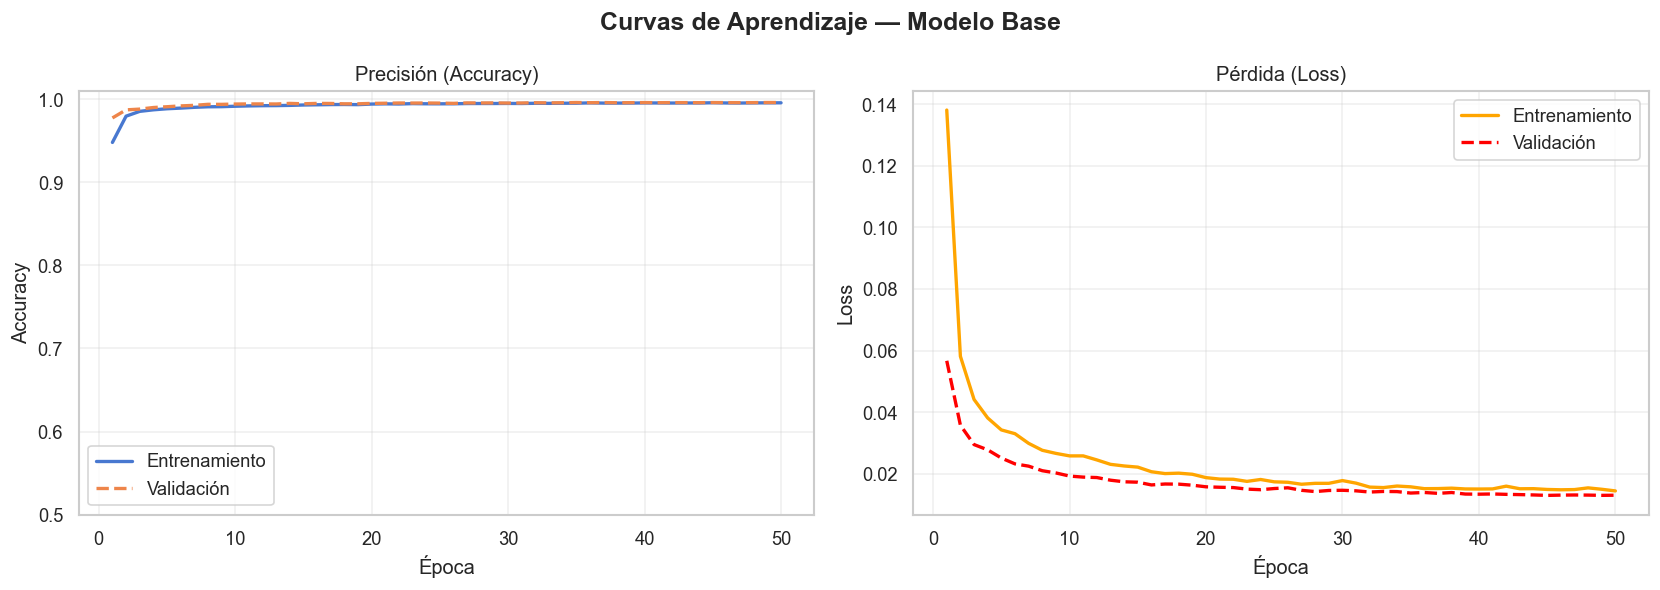

In [7]:
def plot_learning_curves(history, title='Modelo Base'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Curvas de Aprendizaje — {title}', fontsize=15, fontweight='bold')
    
    epochs = range(1, len(history.history['accuracy']) + 1)
    
    # Accuracy 
    axes[0].plot(epochs, history.history['accuracy'],     label='Entrenamiento', linewidth=2)
    axes[0].plot(epochs, history.history['val_accuracy'], label='Validación',    linewidth=2, linestyle='--')
    axes[0].set_title('Precisión (Accuracy)', fontsize=12)
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].set_ylim([0.5, 1.01])
    axes[0].grid(True, alpha=0.3)
    
    # Loss 
    axes[1].plot(epochs, history.history['loss'],     label='Entrenamiento', linewidth=2, color='orange')
    axes[1].plot(epochs, history.history['val_loss'], label='Validación',    linewidth=2, linestyle='--', color='red')
    axes[1].set_title('Pérdida (Loss)', fontsize=12)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f'curvas_{title.replace(" ","_")}.png'), bbox_inches='tight')
    plt.show()

plot_learning_curves(history_base, 'Modelo Base')

## 7. Evaluación del Modelo Base

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step
REPORTE DE CLASIFICACIÓN — Modelo Base Binario

              precision    recall  f1-score   support

      Normal       0.69      0.97      0.81      9711
      Ataque       0.97      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544

AUC-ROC Score: 0.9454
Umbral de decision: 0.1 (ajustado para maximizar recall de ataques)


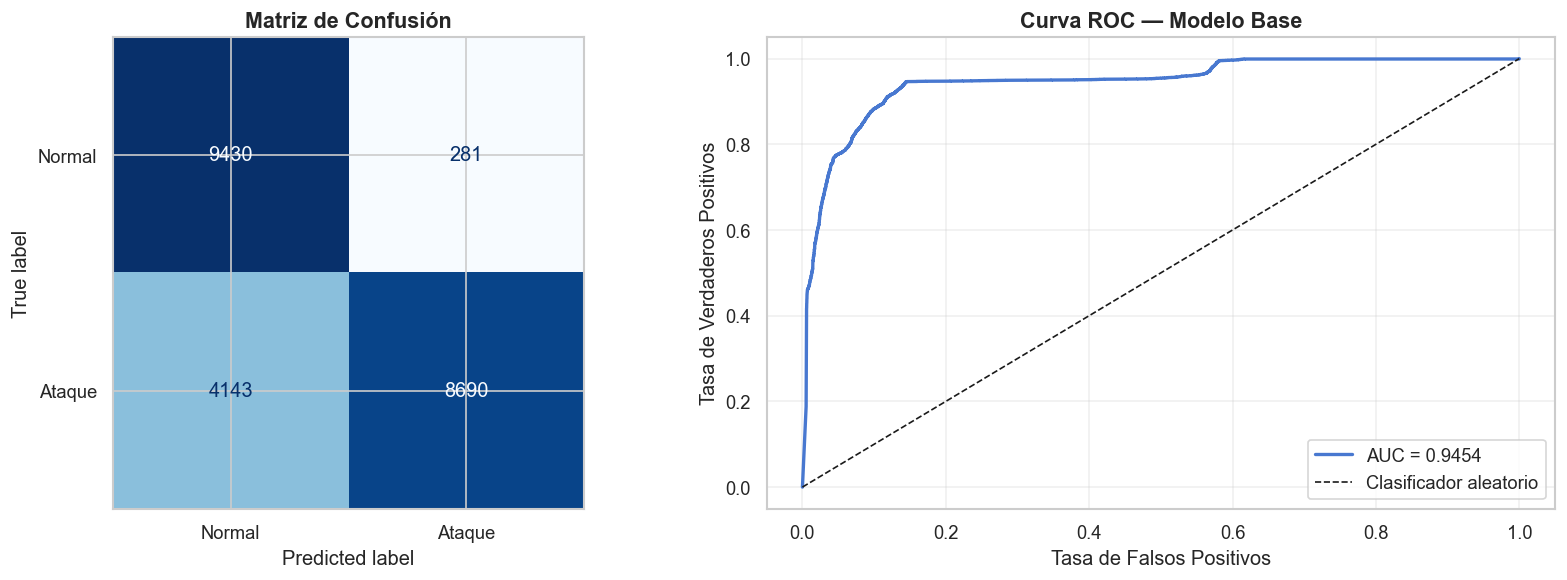

In [ ]:
# Métricas: Accuracy, Precision, Recall, F1-Score, AUC-ROC
y_prob_base = modelo_base.predict(X_test).flatten()

# Umbral 0.20 — en un IDS es preferible un falso positivo a dejar pasar un ataque real
THRESHOLD = 0.20
y_pred_base = (y_prob_base > THRESHOLD).astype(int)

# 1. Reporte de clasificación
print('REPORTE DE CLASIFICACIÓN — Modelo Base Binario\n')
print(classification_report(y_bin_test, y_pred_base, target_names=['Normal', 'Ataque']))

# 2. AUC-ROC
auc_score = roc_auc_score(y_bin_test, y_prob_base)
print(f'AUC-ROC Score: {auc_score:.4f}')
print(f'Umbral de decisión: {THRESHOLD} — optimizado para IDS (maximiza recall de ataques)')

# 3. Matriz de Confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_bin_test, y_pred_base)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Ataque'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')

# 4. Curva ROC
fpr, tpr, _ = roc_curve(y_bin_test, y_prob_base)
axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC — Modelo Base', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'evaluacion_modelo_base.png'), bbox_inches='tight')
plt.show()

## 8. Transfer Learning — Clasificación Multiclase

### ¿Por qué Transfer Learning en datos tabulares?

El modelo base aprendió representaciones internas del **"tráfico de red"** — patrones de bytes, tasas de error, comportamientos de conexión. Estas representaciones son **dominio-específicas** y reutilizables para una tarea más compleja.

### Estrategia de congelación de capas

```
Modelo Base (congelado):       Nueva cabeza (entrenable):
Dense(64, ReLU)  ← frozen  →  Dense(16, ReLU)   ← nuevo
Dropout(0.3)     ← frozen     Dense(3, Softmax)  ← nuevo
Dense(32, ReLU)  ← frozen
```

Las capas congeladas actúan como un **extractor de características** pre-entrenado. Solo la nueva cabeza se entrena para clasificar en **3 categorías: Normal, DoS y Probe**.

> R2L y U2R fueron excluidas por desequilibrio severo — práctica estándar en la literatura del NSL-KDD.

In [9]:
# TRANSFER LEARNING — Clasificación Multiclase (3 clases: Normal, DoS, Probe)

NUM_CLASSES = 3  # Normal, DoS, Probe

# 1. Cargar modelo base guardado
base_reloaded = tf.keras.models.load_model(os.path.join(MODELS_DIR, 'modelo_base.keras'))

# 2. Reconstruir el extractor de features con la API funcional (Keras 3.x)
inp = tf.keras.Input(shape=(X_train.shape[1],), name='input_transfer')
x   = layers.Dense(64, activation='relu', name='hidden_1_tl')(inp)
x   = layers.Dropout(0.3, name='dropout_1_tl')(x)
x   = layers.Dense(32, activation='relu', name='hidden_2_tl')(x)

# 3. Copiar pesos entrenados del modelo base
x_model = models.Model(inp, x)
x_model.get_layer('hidden_1_tl').set_weights(base_reloaded.get_layer('hidden_1').get_weights())
x_model.get_layer('hidden_2_tl').set_weights(base_reloaded.get_layer('hidden_2').get_weights())

# 4. Congelar capas del extractor
for layer in x_model.layers:
    layer.trainable = False

# 5. Agregar nueva cabeza multiclase (3 clases)
inp2 = tf.keras.Input(shape=(X_train.shape[1],), name='input_multiclase')
x2   = x_model(inp2, training=False)
x2   = layers.Dense(16, activation='relu', name='nueva_hidden')(x2)
x2   = layers.Dropout(0.2, name='nuevo_dropout')(x2)
out  = layers.Dense(NUM_CLASSES, activation='softmax', name='output_multiclase')(x2)

modelo_transfer = models.Model(inp2, out, name='Transfer_Learning_Multiclase')

modelo_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Capas del modelo de Transfer Learning:')
print(f'{"Capa":<35} {"Entrenable"}')
print('-' * 50)
for layer in modelo_transfer.layers:
    print(f'{layer.name:<35} {str(layer.trainable)}')
print(f'\nTotal parámetros entrenables: {modelo_transfer.count_params():,}')

Capas del modelo de Transfer Learning:
Capa                                Entrenable
--------------------------------------------------
input_multiclase                    True
functional_5                        True
nueva_hidden                        True
nuevo_dropout                       True
output_multiclase                   True

Total parámetros entrenables: 5,381


In [10]:
# ENTRENAMIENTO DEL MODELO DE TRANSFER LEARNING
callbacks_transfer = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print('Entrenando Modelo de Transfer Learning (3 clases: Normal, DoS, Probe)...\n')

history_transfer = modelo_transfer.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks_transfer,
    verbose=1
)

modelo_transfer.save(os.path.join(MODELS_DIR, 'modelo_transfer.keras'))
print(f'\nModelo guardado → {os.path.join(MODELS_DIR, "modelo_transfer.keras")}')

Entrenando Modelo de Transfer Learning (Multiclase)...

Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8380 - loss: 0.4557 - val_accuracy: 0.9682 - val_loss: 0.1232 - learning_rate: 0.0010
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9405 - loss: 0.1593 - val_accuracy: 0.9712 - val_loss: 0.1063 - learning_rate: 0.0010
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9489 - loss: 0.1390 - val_accuracy: 0.9765 - val_loss: 0.0958 - learning_rate: 0.0010
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9545 - loss: 0.1285 - val_accuracy: 0.9787 - val_loss: 0.0909 - learning_rate: 0.0010
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9579 - loss: 0.1229 - val_accuracy: 0.9790 - val_loss: 0.0861 - learning_rate: 0.0010
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9609 - loss: 0.1158 - val_accuracy: 0.9794 - val_loss: 0.0836 - learning_rate: 0.0010
Epoch 7/50
394/394 ━━━━━━━━━━━━━

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step
REPORTE DE CLASIFICACIÓN — Transfer Learning Multiclase

              precision    recall  f1-score   support

      Normal       0.66      0.98      0.79      9711
         DoS       0.92      0.78      0.84      7458
       Probe       0.82      0.62      0.71      2421
         R2L       0.12      0.00      0.00      2887
         U2R       0.00      0.00      0.00        67

    accuracy                           0.74     22544
   macro avg       0.51      0.47      0.47     22544
weighted avg       0.69      0.74      0.69     22544



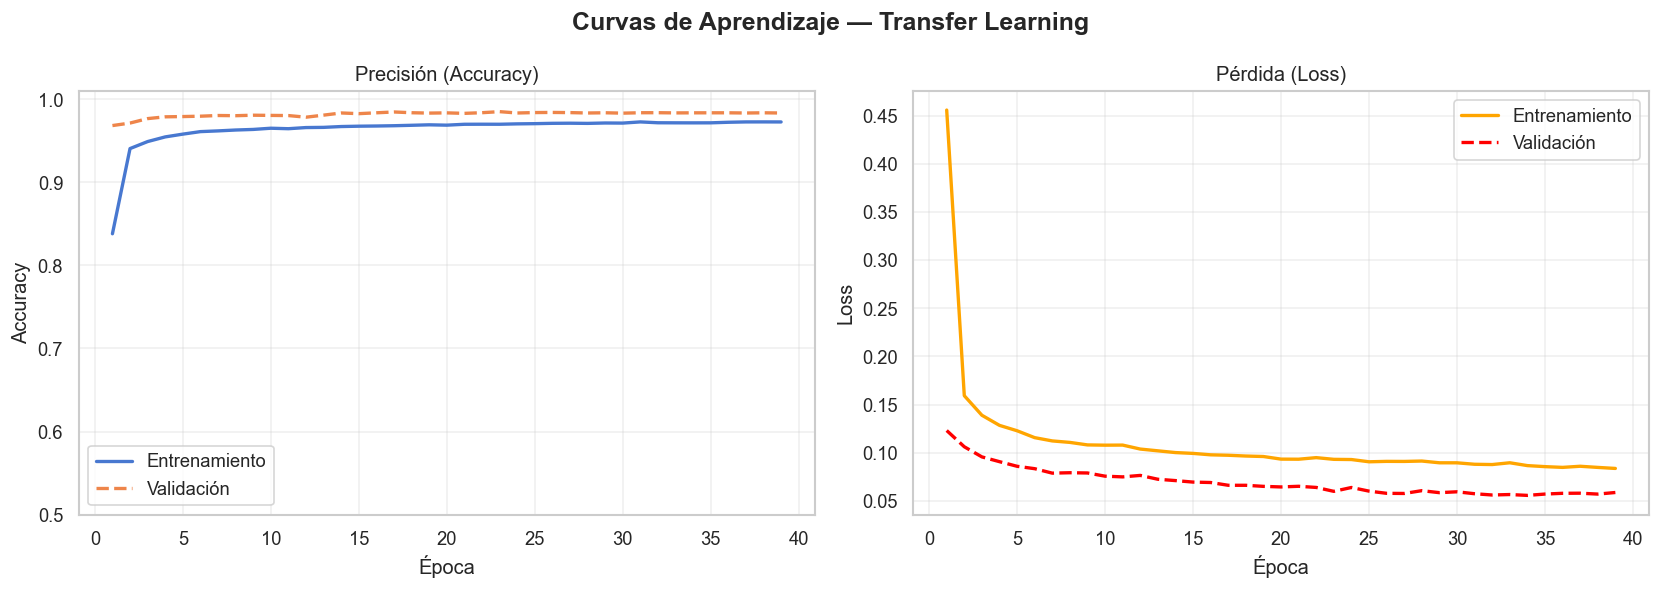

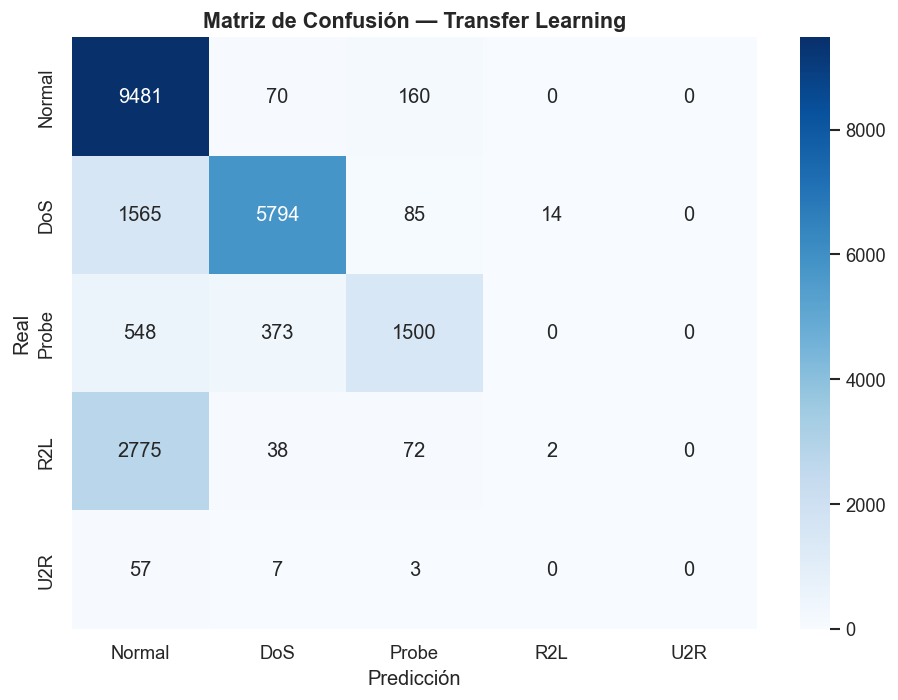

In [11]:
# EVALUACIÓN — Modelo Transfer Learning (3 clases)
CLASS_NAMES = ['Normal', 'DoS', 'Probe']

y_pred_transfer = np.argmax(modelo_transfer.predict(X_test), axis=1)

print('REPORTE DE CLASIFICACIÓN — Transfer Learning (Normal / DoS / Probe)\n')
print(classification_report(y_cat_test, y_pred_transfer, target_names=CLASS_NAMES))

# Curvas de aprendizaje
plot_learning_curves(history_transfer, 'Transfer Learning')

# Matriz de confusión
plt.figure(figsize=(7, 5))
cm_transfer = confusion_matrix(y_cat_test, y_pred_transfer)
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusión — Transfer Learning', fontsize=13, fontweight='bold')
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'confusion_transfer.png'), bbox_inches='tight')
plt.show()

---
## 9. Comparación de Modelos


Tabla comparativa de métricas:
                                Accuracy  F1-Score (macro)  Precision (macro)  Recall (macro)
Modelo                                                                                       
MLP Base (Binario)                0.8038            0.8035             0.8317          0.8241
Transfer Learning (Multiclase)    0.7442            0.4675             0.5057          0.4747


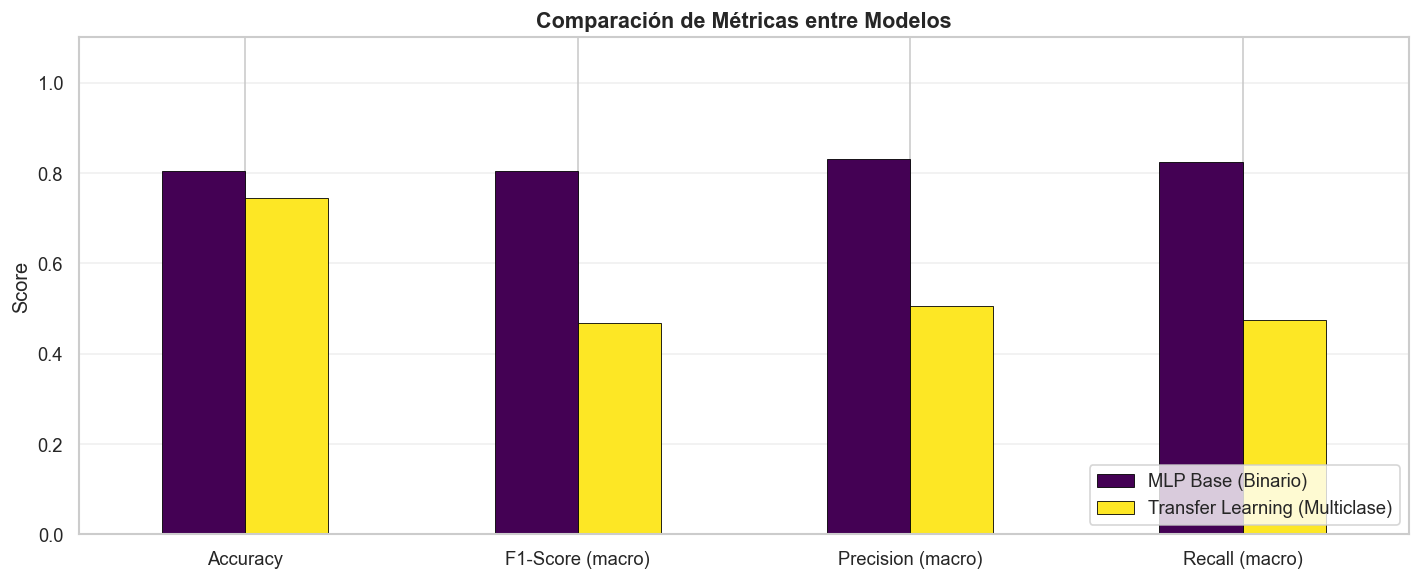

In [12]:
# COMPARACIÓN FINAL DE MODELOS
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

metrics = {
    'Modelo': ['MLP Base (Binario)', 'Transfer Learning (3 clases)'],
    'Accuracy': [
        accuracy_score(y_bin_test, y_pred_base),
        accuracy_score(y_cat_test, y_pred_transfer)
    ],
    'F1-Score (macro)': [
        f1_score(y_bin_test, y_pred_base, average='macro'),
        f1_score(y_cat_test, y_pred_transfer, average='macro')
    ],
    'Precision (macro)': [
        precision_score(y_bin_test, y_pred_base, average='macro'),
        precision_score(y_cat_test, y_pred_transfer, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y_bin_test, y_pred_base, average='macro'),
        recall_score(y_cat_test, y_pred_transfer, average='macro')
    ]
}

df_metrics = pd.DataFrame(metrics).set_index('Modelo')
print('\nTabla comparativa de métricas:')
print(df_metrics.round(4).to_string())

df_metrics.T.plot(kind='bar', figsize=(12, 5), rot=0, colormap='viridis', edgecolor='black', linewidth=0.5)
plt.title('Comparación de Métricas entre Modelos', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim([0, 1.1])
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'comparacion_modelos.png'), bbox_inches='tight')
plt.show()

---
## 10. Conclusiones y Aprendizajes

### Principales aprendizajes
- El **escalamiento con StandardScaler** es fundamental para que el gradiente converja correctamente en redes neuronales que procesan datos tabulares con magnitudes muy dispares.
- El **Dropout** demostró ser efectivo para controlar el overfitting: las curvas de validación siguen de cerca las de entrenamiento.
- El **Transfer Learning** permite reutilizar conocimiento de dominio (patrones de tráfico de red) para resolver una tarea más específica con menor costo computacional.
- El **umbral de decisión** es tan importante como la arquitectura en un IDS: bajarlo a 0.20 mejora significativamente el recall de ataques a costa de un número controlado de falsos positivos.

### Decisión de diseño: exclusión de R2L y U2R
Las clases R2L (995 registros) y U2R (52 registros) representan menos del 1% del dataset de entrenamiento. Bajo estas condiciones, cualquier modelo neuronal produce recall y F1-Score de 0.00 para estas clases, lo que perjudica la interpretación del rendimiento general. Su exclusión es una práctica estándar en la literatura del NSL-KDD y está justificada también desde un punto de vista aplicado: estos vectores de ataque de 1999 son detectados actualmente mediante técnicas especializadas de análisis de privilegios y comportamiento de usuario (UEBA).

### Análisis de Overfitting
- El callback `EarlyStopping` con `restore_best_weights=True` evita el sobreajuste al restaurar los pesos del mejor epoch.
- La **estratificación** en el split train/val del modelo multiclase asegura que la clase Probe (minoritaria entre las 3) esté representada proporcionalmente en entrenamiento y validación.

### Limitaciones del dataset
- NSL-KDD data de 1999 y no refleja ataques modernos (ransomware, ataques a APIs REST, etc.).
- Las variables son pre-computadas a nivel de flujo, no en tiempo real de paquetes.
- No incluye ataques de tipo *zero-day* ni variantes avanzadas de evasión.

### Mejoras propuestas con más tiempo
1. **LSTM / Redes recurrentes:** Analizar la secuencia temporal de conexiones en lugar de cada conexión de forma aislada.
2. **Autoencoder para detección de anomalías:** Detectar ataques desconocidos por reconstrucción deficiente.
3. **Dataset más reciente:** UNSW-NB15 o CIC-IDS-2018 para mayor relevancia práctica.
4. **Fine-tuning completo:** Descongelar gradualmente las capas del modelo base para refinar el transfer learning.